In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12


In [4]:
df = pd.read_csv('../data/ticketing/delhi_metro_updated.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head(10)

Shape: (150000, 10)

Columns:
['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare', 'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks']


,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak
5,96371,2024-07-10,Kalkaji Mandir,Shivaji Park,3.91,29.20,30.64,22.0,Tourist Card,NaN
6,49743,2022-09-02,Mandi House,Jasola Vihar,1.49,175.32,33.45,14.0,Tourist Card,peak
7,47390,2023-12-07,Mandi House,Central Secretariat,7.38,167.59,50.69,18.0,Tourist Card,festival
8,58379,2024-05-05,AIIMS,Chandni Chowk,2.57,125.25,81.71,24.0,Single,weekend
9,69048,2022-07-05,New Delhi,Jasola Vihar,7.58,151.39,37.76,19.0,Tourist Card,peak


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  str    
 2   From_Station        150000 non-null  str    
 3   To_Station          150000 non-null  str    
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  str    
 9   Remarks             123743 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 11.4 MB


In [6]:
df.describe()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,150000.000000,150000.000000,150000.000000,150000.000000,148500.000000
mean,75000.500000,5.490446,105.116503,62.474807,20.003522
std,43301.414527,4.980333,54.879494,33.207161,4.468134
min,1.000000,0.500000,10.000000,5.000000,4.000000
25%,37500.750000,1.940000,57.570000,33.687500,17.000000
50%,75000.500000,3.960000,105.170000,62.520000,20.000000
75%,112500.250000,7.420000,152.572500,91.190000,23.000000
max,150000.000000,63.030000,200.000000,120.000000,41.000000


In [7]:
df.describe(include = 'object')

,Date,From_Station,To_Station,Ticket_Type,Remarks
count,150000,150000,150000,148500,123743
unique,1095,663,24,4,5
top,2024-08-10,Rajiv Chowk,Hauz Khas,Tourist Card,off-peak
freq,183,15593,6372,59193,24859


In [8]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

             Missing Count  Missing %
Remarks              26257       17.5
Passengers            1500        1.0
Ticket_Type           1500        1.0


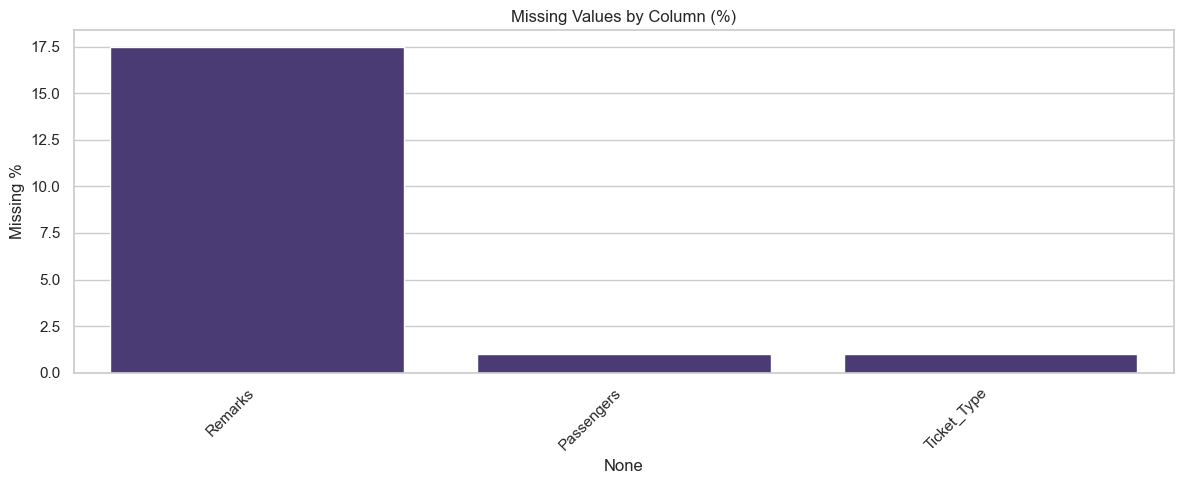

In [9]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing Count'] > 0])

if missing['Missing Count'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    missing_cols = missing[missing['Missing Count'] > 0]
    sns.barplot(x=missing_cols.index, y='Missing %', data=missing_cols, ax=ax)
    ax.set_title('Missing Values by Column (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found!")

In [10]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count} ({(dup_count/len(df)*100):.2f}%)")

if dup_count > 0:
    print("\nSample duplicates:")
    display(df[df.duplicated(keep=False)].head(10))

Duplicate rows: 0 (0.00%)


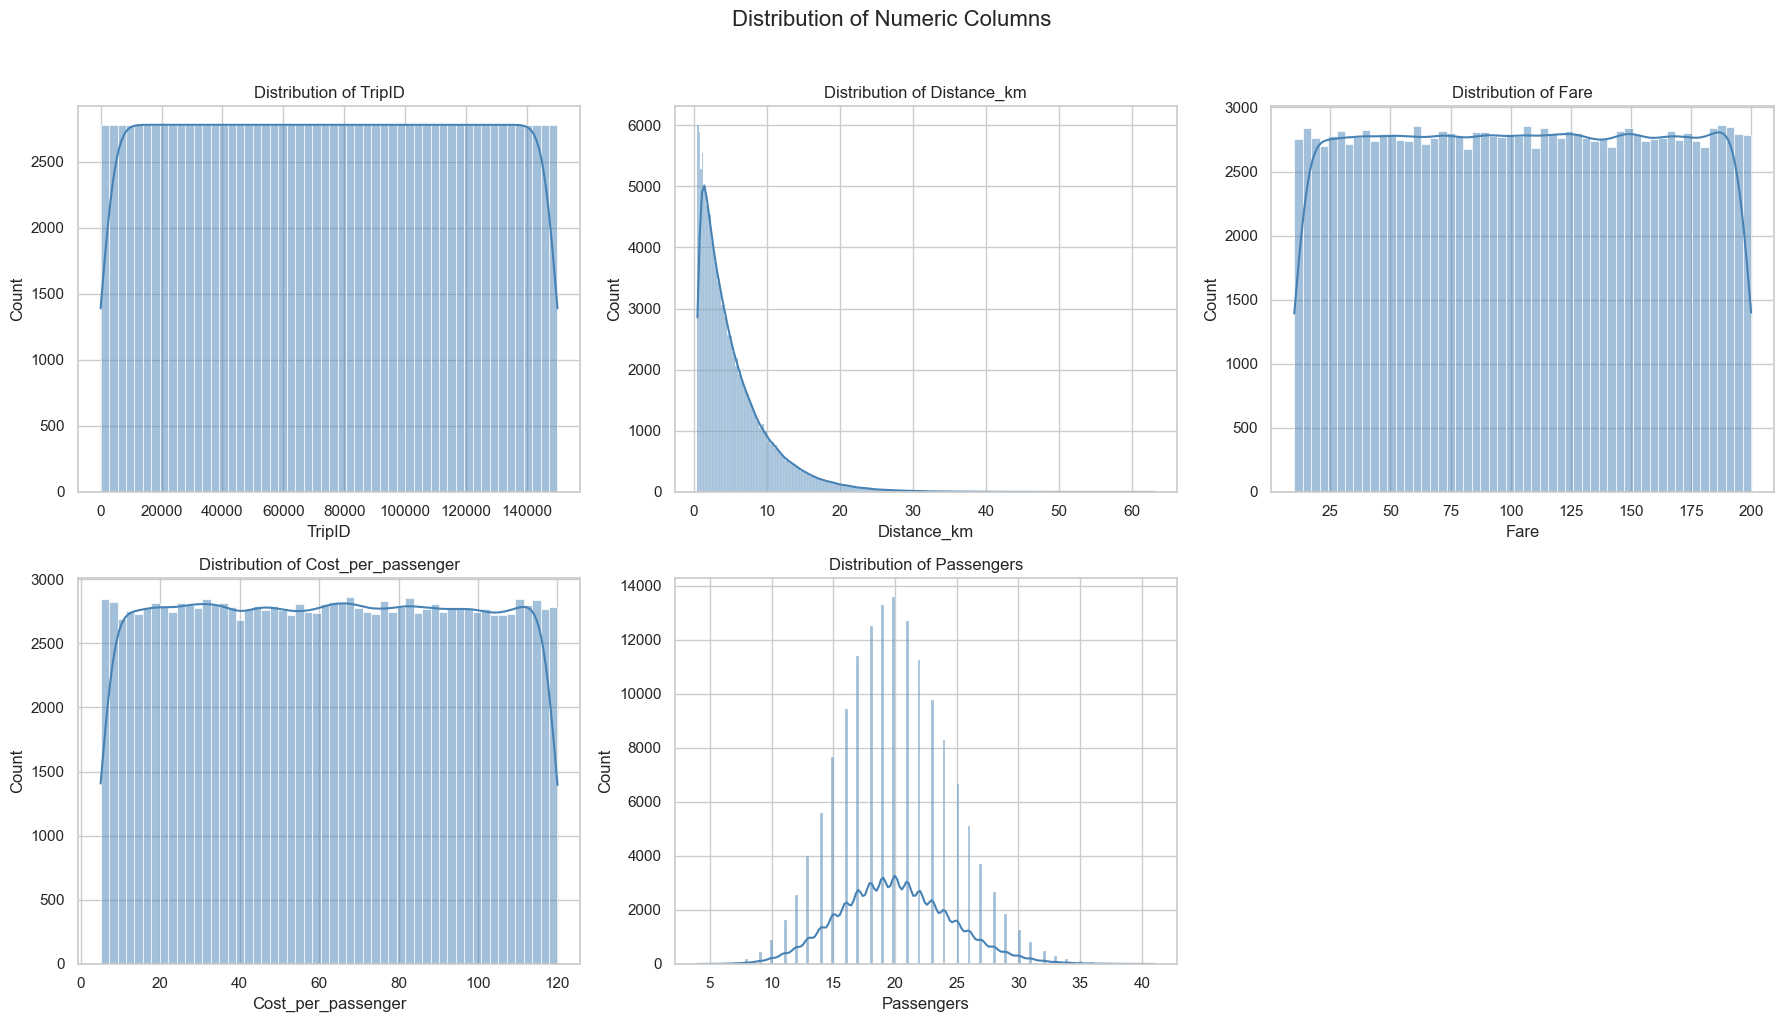

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten() if len(numeric_cols) > 1 else [axes]

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Numeric Columns', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


'Date' has 1095 unique values — top 10:
Date
2024-08-10    183
2024-08-01    175
2022-04-07    173
2022-07-05    172
2022-08-23    171
2024-09-07    170
2023-06-14    170
2022-08-24    169
2022-06-14    168
2023-09-12    165
Name: count, dtype: int64

'From_Station' has 663 unique values — top 10:
From_Station
Rajiv Chowk            15593
Noida City Centre      12049
New Delhi               8173
Mandi House             8044
Dilshad Garden          4461
Chandni Chowk           4420
Kalkaji Mandir          4417
Central Secretariat     4413
Janakpuri West          4412
Laxmi Nagar             4408
Name: count, dtype: int64


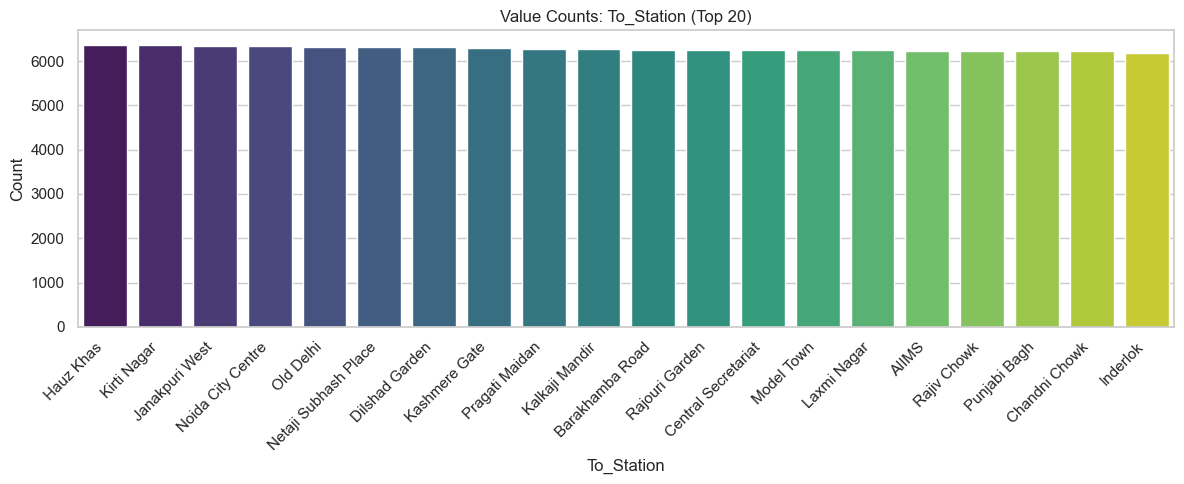

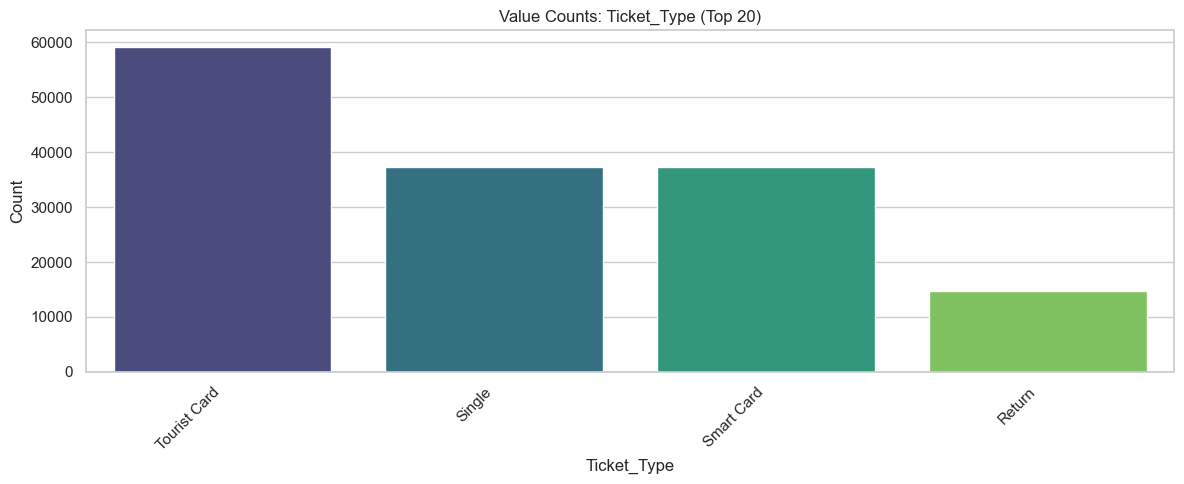

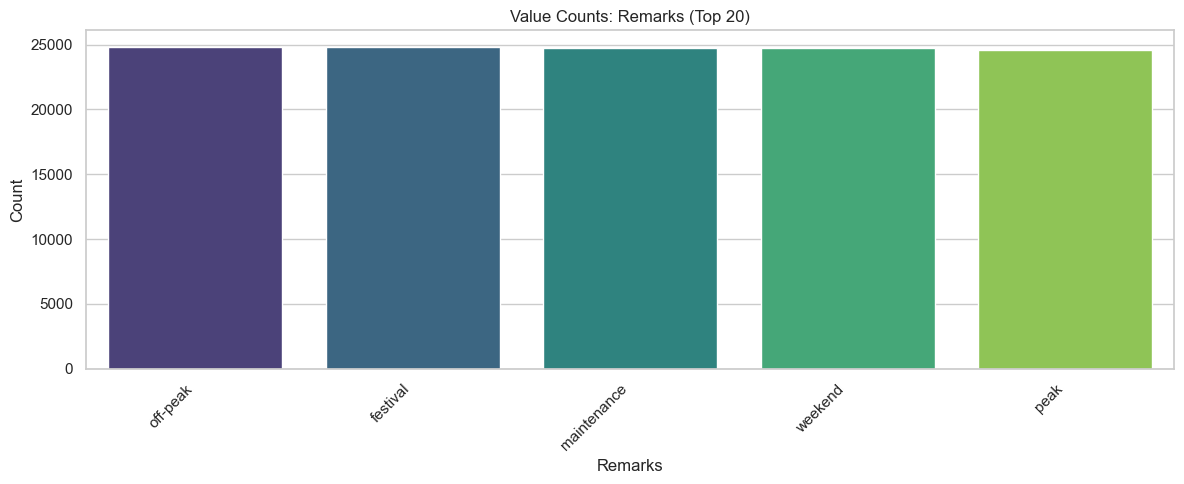

In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    n_unique = df[col].nunique()
    if n_unique <= 30:
        fig, ax = plt.subplots(figsize=(12, 5))
        value_counts = df[col].value_counts().head(20)
        sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax, palette='viridis')
        ax.set_title(f'Value Counts: {col} (Top 20)')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n'{col}' has {n_unique} unique values — top 10:")
        print(df[col].value_counts().head(10))

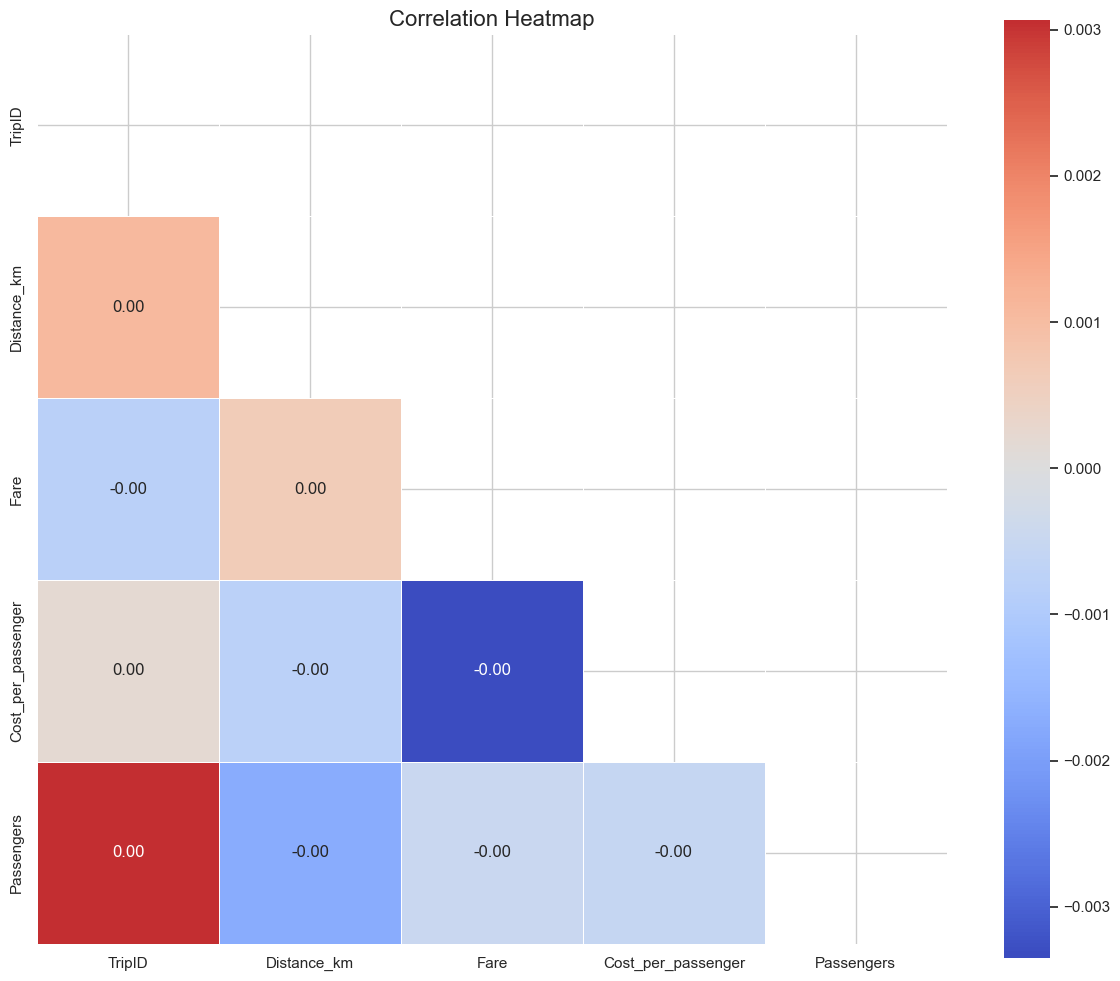

In [13]:
if len(numeric_cols) > 1:
    fig, ax = plt.subplots(figsize=(12, 10))
    corr_matrix = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, ax=ax,
                square=True, linewidths=0.5)
    ax.set_title('Correlation Heatmap', fontsize=16)
    plt.tight_layout()
    plt.show()


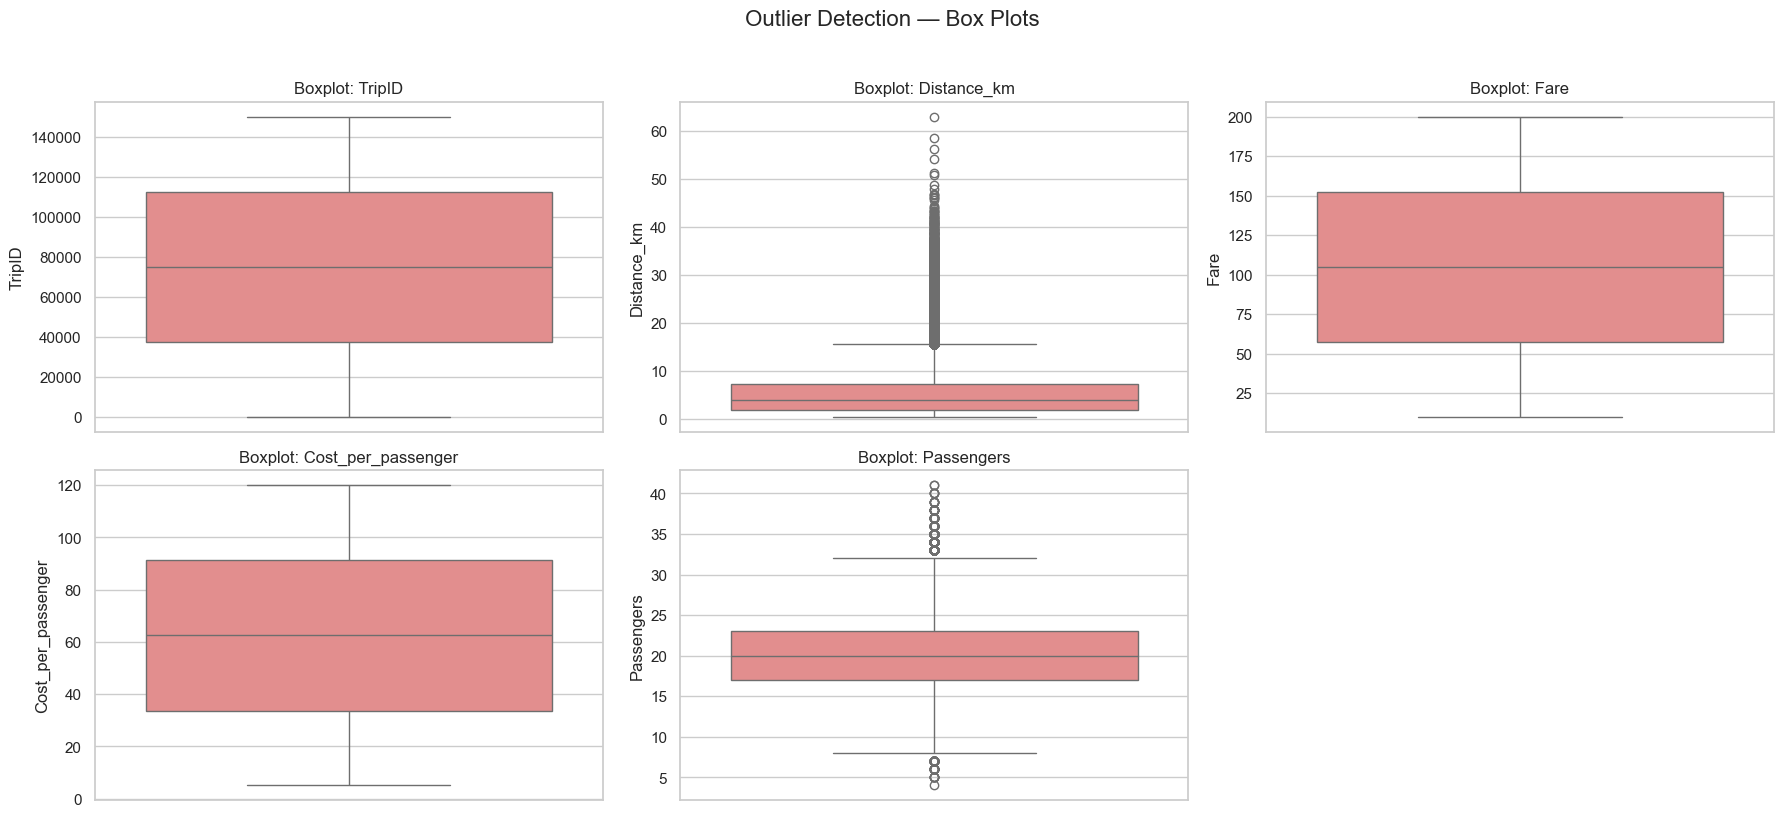

In [14]:
if len(numeric_cols) > 0:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten() if len(numeric_cols) > 1 else [axes]

    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col].dropna(), ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Boxplot: {col}')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Outlier Detection — Box Plots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


In [15]:
date_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            pd.to_datetime(df[col].head(100))
            date_cols.append(col)
        except:
            pass

if date_cols:
    print(f"Detected date columns: {date_cols}")
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col])

    if len(numeric_cols) > 0:
        target_col = numeric_cols[0]
        daily = df.groupby(df[date_col].dt.date)[target_col].mean()

        fig, ax = plt.subplots(figsize=(16, 6))
        daily.plot(ax=ax, color='steelblue', linewidth=1)
        ax.set_title(f'Daily Trend: {target_col}')
        ax.set_xlabel('Date')
        ax.set_ylabel(target_col)
        plt.tight_layout()
        plt.show()

    df['day_of_week'] = df[date_col].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    if len(numeric_cols) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        day_avg = df.groupby('day_of_week')[target_col].mean().reindex(day_order)
        sns.barplot(x=day_avg.index, y=day_avg.values, ax=ax, palette='viridis')
        ax.set_title(f'Average {target_col} by Day of Week')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        plt.tight_layout()
        plt.show()

    if df[date_col].dt.hour.nunique() > 1:
        fig, ax = plt.subplots(figsize=(12, 5))
        hourly = df.groupby(df[date_col].dt.hour)[target_col].mean()
        hourly.plot(kind='bar', ax=ax, color='coral')
        ax.set_title(f'Average {target_col} by Hour of Day')
        ax.set_xlabel('Hour')
        plt.tight_layout()
        plt.show()
else:
    print("No date columns auto-detected. Check column names manually.")


No date columns auto-detected. Check column names manually.


Station column found: 'From_Station'
Total stations: 663


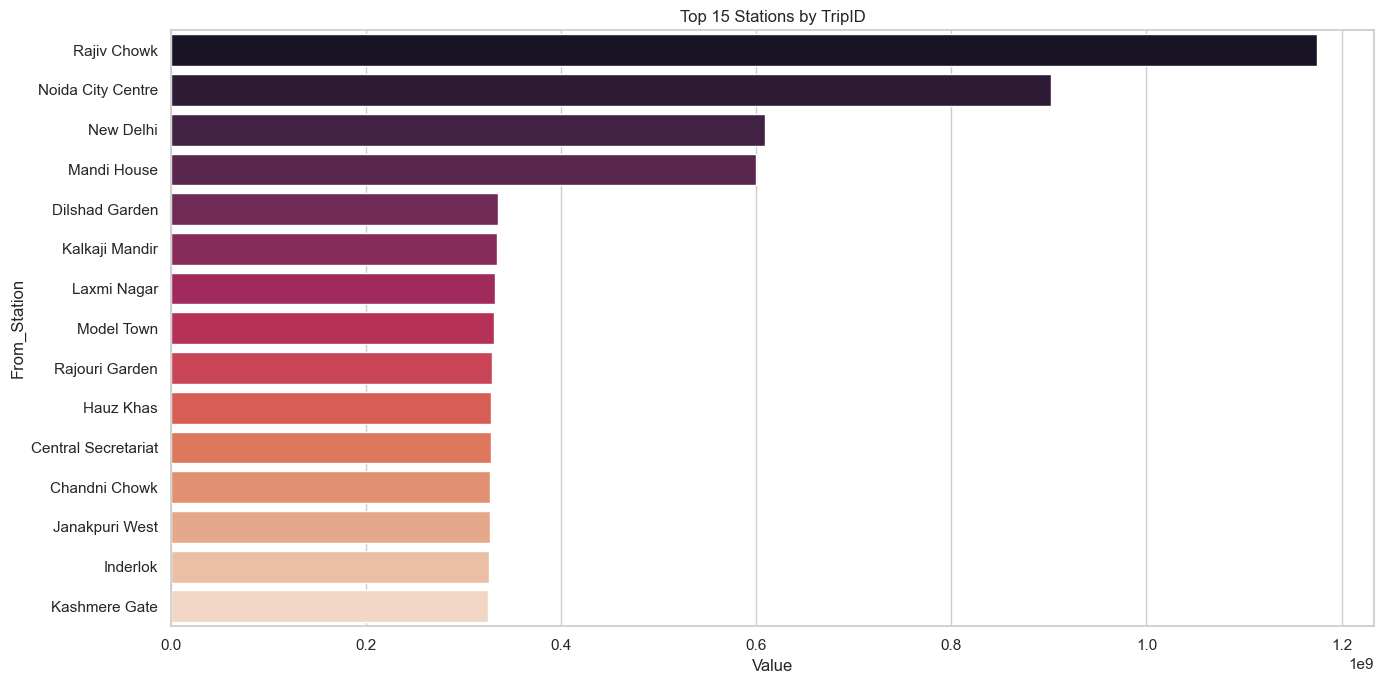

In [16]:
station_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['station', 'stop', 'location', 'name'])]

if station_cols:
    station_col = station_cols[0]
    print(f"Station column found: '{station_col}'")
    print(f"Total stations: {df[station_col].nunique()}")

    if len(numeric_cols) > 0:
        top_stations = df.groupby(station_col)[numeric_cols[0]].sum().nlargest(15)
    else:
        top_stations = df[station_col].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(14, 7))
    sns.barplot(x=top_stations.values, y=top_stations.index, ax=ax, palette='rocket')
    ax.set_title(f'Top 15 Stations by {numeric_cols[0] if numeric_cols else "Record Count"}')
    ax.set_xlabel('Value')
    plt.tight_layout()
    plt.show()
else:
    print("No station column auto-detected. Check column names manually.")


In [17]:
print("=" * 60)
print("EDA SUMMARY — Delhi Metro Dataset")
print("=" * 60)
print(f"Total Records      : {len(df):,}")
print(f"Total Columns      : {len(df.columns)}")
print(f"Numeric Columns    : {len(numeric_cols)}")
print(f"Categorical Columns: {len(cat_cols)}")
print(f"Date Columns       : {len(date_cols)}")
print(f"Missing Values     : {df.isnull().sum().sum():,}")
print(f"Duplicate Rows     : {df.duplicated().sum():,}")
print(f"Memory Usage       : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 60)

EDA SUMMARY — Delhi Metro Dataset
Total Records      : 150,000
Total Columns      : 10
Numeric Columns    : 5
Categorical Columns: 5
Date Columns       : 0
Missing Values     : 29,257
Duplicate Rows     : 0
Memory Usage       : 47.64 MB
